# Visualization

Visualizing data is one of the most significant things in machine learning. Because it helps you to understand how data is and what you can do with that data...

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [13]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "viridis"

### Load the data

In [14]:
data_url = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
data = pd.read_csv(data_url + "video_games_sales.csv")

In [15]:
data = data.dropna()

### Explore the data

In [16]:
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6825 entries, 0 to 16706
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             6825 non-null   object 
 1   Platform         6825 non-null   object 
 2   Year_of_Release  6825 non-null   float64
 3   Genre            6825 non-null   object 
 4   Publisher        6825 non-null   object 
 5   NA_Sales         6825 non-null   float64
 6   EU_Sales         6825 non-null   float64
 7   JP_Sales         6825 non-null   float64
 8   Other_Sales      6825 non-null   float64
 9   Global_Sales     6825 non-null   float64
 10  Critic_Score     6825 non-null   float64
 11  Critic_Count     6825 non-null   float64
 12  User_Score       6825 non-null   object 
 13  User_Count       6825 non-null   float64
 14  Developer        6825 non-null   object 
 15  Rating           6825 non-null   object 
dtypes: float64(9), object(7)
memory usage: 906.4+ KB


In [18]:
data["User_Score"] = data["User_Score"].astype("float64")
data["User_Count"] = data["User_Count"].astype("int64")
data["Year_of_Release"] = data["Year_of_Release"].astype("int64")
data["Critic_Count"] = data["Critic_Count"].astype("int64")

In [19]:
data.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000
mean,2007.436777,0.394484,0.236089,0.064158,0.082677,0.777590,70.272088,28.931136,7.185626,174.722344
std,4.211248,0.967385,0.687330,0.287570,0.269871,1.963443,13.868572,19.224165,1.439942,587.428538
min,1985.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.500000,4.000000
25%,2004.000000,0.060000,0.020000,0.000000,0.010000,0.110000,62.000000,14.000000,6.500000,11.000000
50%,2007.000000,0.150000,0.060000,0.000000,0.020000,0.290000,72.000000,25.000000,7.500000,27.000000
75%,2011.000000,0.390000,0.210000,0.010000,0.070000,0.750000,80.000000,39.000000,8.200000,89.000000
max,2016.000000,41.360000,28.960000,6.500000,10.570000,82.530000,98.000000,113.000000,9.600000,10665.000000


In [20]:
data.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

In [21]:
data.shape

(6825, 16)

In [22]:
useful_columns =  ["Name","Platform","Year_of_Release","Genre","Global_Sales","Critic_Score","Critic_Count","User_Score","User_Count","Rating"]
data[useful_columns].head()

,Name,Platform,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006,Sports,82.53,76.0,51,8.0,322,E
2,Mario Kart Wii,Wii,2008,Racing,35.52,82.0,73,8.3,709,E
3,Wii Sports Resort,Wii,2009,Sports,32.77,80.0,73,8.0,192,E
6,New Super Mario Bros.,DS,2006,Platform,29.80,89.0,65,8.5,431,E
7,Wii Play,Wii,2006,Misc,28.92,58.0,41,6.6,129,E


## DataFrame.Plot()

<Axes: xlabel='Year_of_Release'>

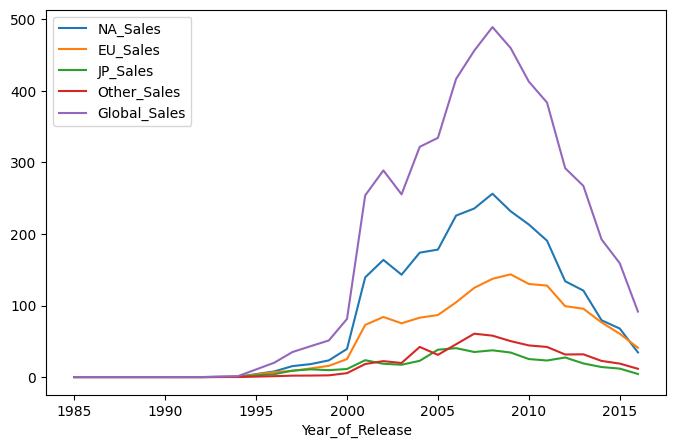

In [24]:
data[[x for x in data.columns if "Sales" in x] + ["Year_of_Release"]].groupby("Year_of_Release").sum().plot()

<Axes: xlabel='Year_of_Release'>

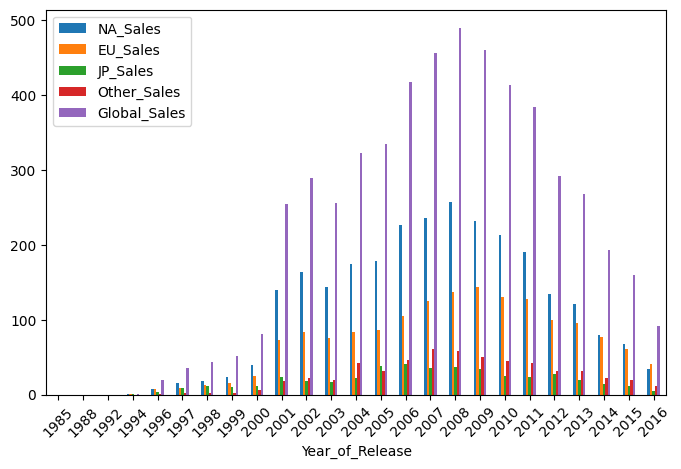

In [26]:
data[[x for x in data.columns if "Sales" in x] + ["Year_of_Release"]].groupby("Year_of_Release").sum().plot(kind = "bar",rot = 45)

## Seaborn

### sns.pairplot()

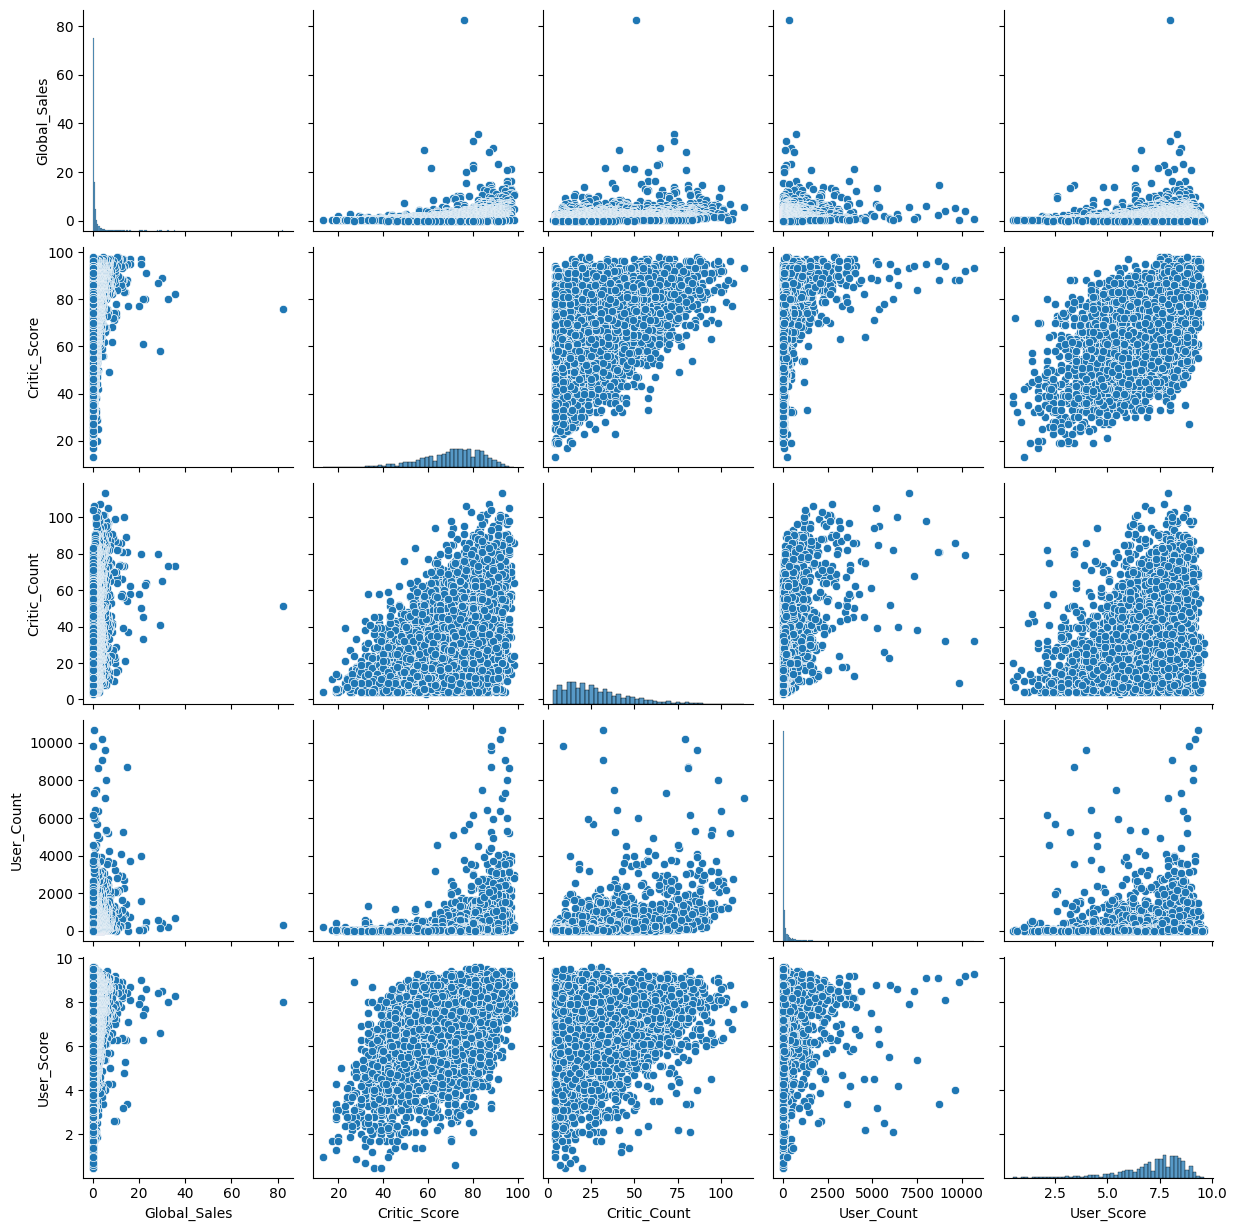

In [27]:
sns.pairplot(data[["Global_Sales","Critic_Score","Critic_Count","User_Count","User_Score"]])

### sns.histplot()

<Axes: xlabel='Critic_Score', ylabel='Density'>

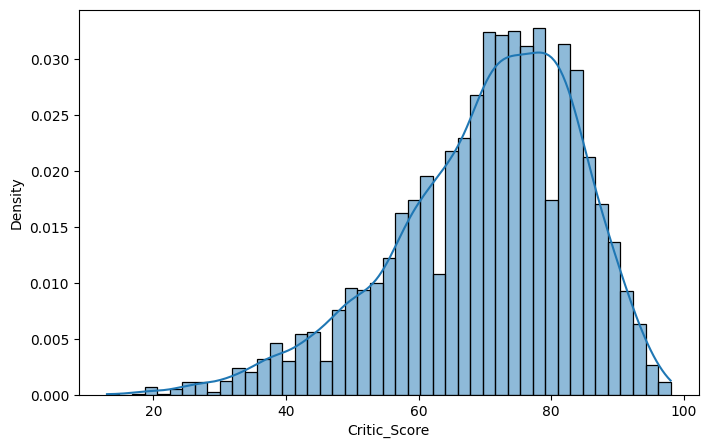

In [29]:
sns.histplot(data = data["Critic_Score"],kde = True,stat = "density")

<Axes: xlabel='User_Score', ylabel='Density'>

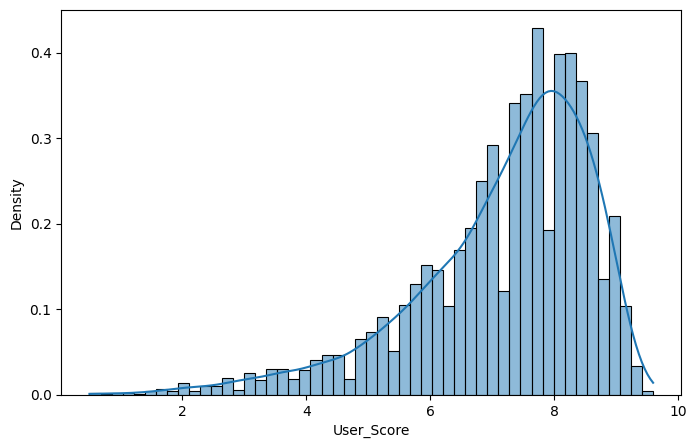

In [30]:
sns.histplot(data = data["User_Score"],kde = True,stat = "density")

In [31]:
data["User_Score"].value_counts()

User_Score
7.8    294
8.0    259
8.2    258
8.5    238
7.9    235
      ... 
0.5      2
0.9      1
0.6      1
1.3      1
0.7      1
Name: count, Length: 89, dtype: int64

### sns.jointplot():
* To look more closely at the relationship between two numerical variables, you can use joint plot, which is a cross between a scatter plot and histogram.

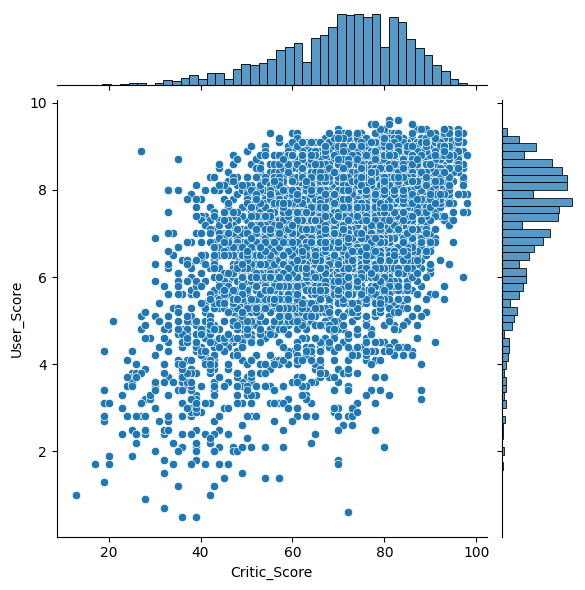

In [32]:
sns.jointplot(x = "Critic_Score",y ="User_Score",data = data,kind = "scatter")

### sns.boxplot()

<Axes: xlabel='Critic_Score', ylabel='Platform'>

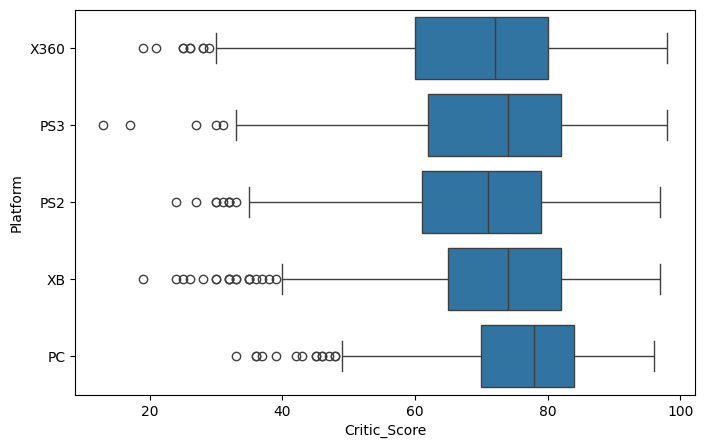

In [33]:
top_platforms = (data["Platform"].value_counts().sort_values(ascending = False).head(5).index.values)

sns.boxplot(y = "Platform", x = "Critic_Score",data = data[data["Platform"].isin(top_platforms)],orient = "h")

In [36]:
data.dtypes

Name                object
Platform            object
Year_of_Release      int64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count         int64
User_Score         float64
User_Count           int64
Developer           object
Rating              object
dtype: object

In [38]:
data_numerics = data.select_dtypes(include =["int","float"])

<Axes: >

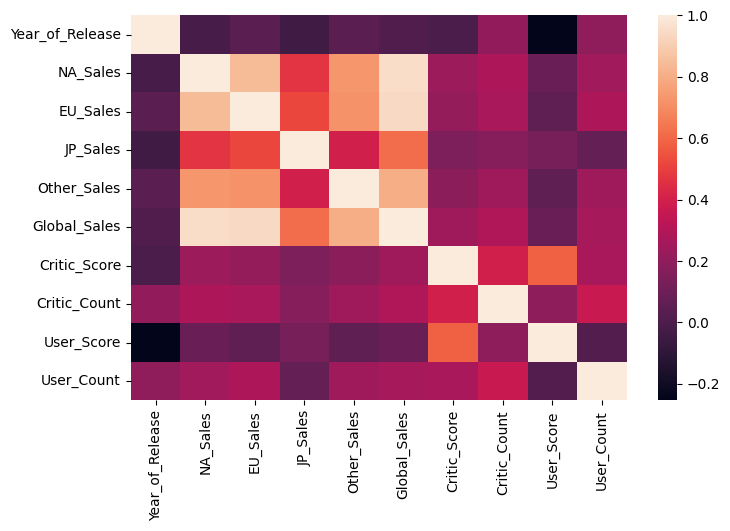

In [41]:
numeric_corr_matrix = data_numerics.corr()
sns.heatmap(numeric_corr_matrix)